<a href="https://colab.research.google.com/github/nrozylo/projekt_2026/blob/main/projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projekt: Energy Consumption (Linear Regression)

## Wczytanie i przegląd danych

In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [453]:
!wget https://raw.githubusercontent.com/nrozylo/projekt_2026/refs/heads/main/train_energy_data.csv
df = pd.read_csv('train_energy_data.csv')
df.head()

--2026-06-14 21:15:43--  https://raw.githubusercontent.com/nrozylo/projekt_2026/refs/heads/main/train_energy_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44806 (44K) [text/plain]
Saving to: ‘train_energy_data.csv.33’

train_energy_data.c 100%[===================>]  43.76K  --.-KB/s    in 0.007s  

2026-06-14 21:15:43 (5.89 MB/s) - ‘train_energy_data.csv.33’ saved [44806/44806]



,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [454]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [455]:
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [456]:
df["Building Type"].value_counts()

,count
Building Type,
Residential,347
Commercial,336
Industrial,317


In [457]:
df["Day of Week"].value_counts()

,count
Day of Week,
Weekday,507
Weekend,493


## Wstępna anliza (wizualizacja)

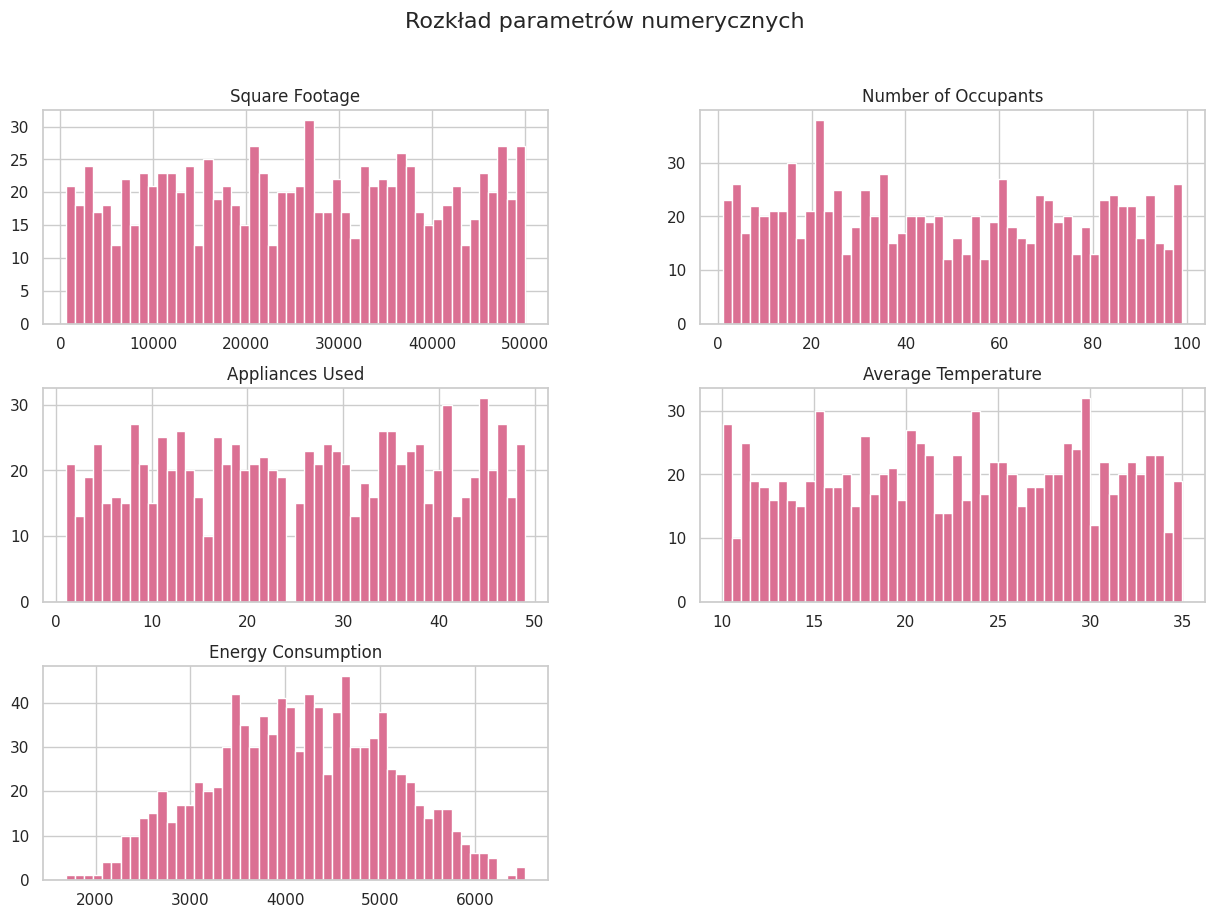

In [458]:
%matplotlib inline
df.hist(bins=50, figsize=(15,10), color='palevioletred')
plt.suptitle("Rozkład parametrów numerycznych", fontsize=16)
plt.show()

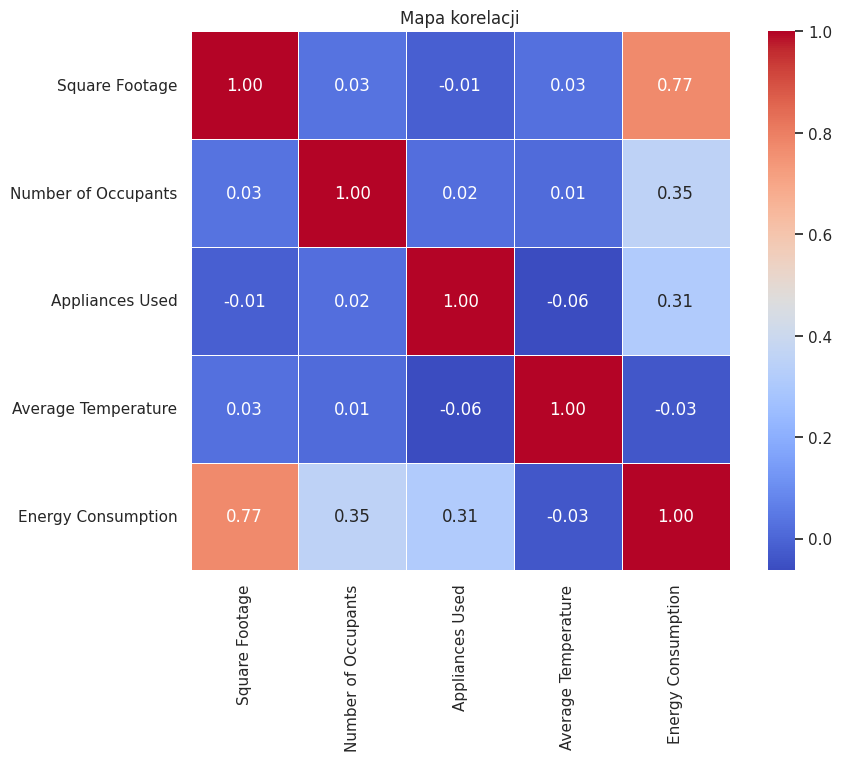

Korelacja cech z Energy Consumption:
Energy Consumption     1.000000
Square Footage         0.774873
Number of Occupants    0.354485
Appliances Used        0.312792
Average Temperature   -0.034487


In [459]:
plt.figure(figsize=(10, 7))
korelacja = df.select_dtypes(include=np.number).corr()
sns.heatmap(korelacja, annot=True, fmt='0.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Mapa korelacji')
plt.show()

print("Korelacja cech z Energy Consumption:")
print(korelacja['Energy Consumption'].sort_values(ascending=False).to_string())

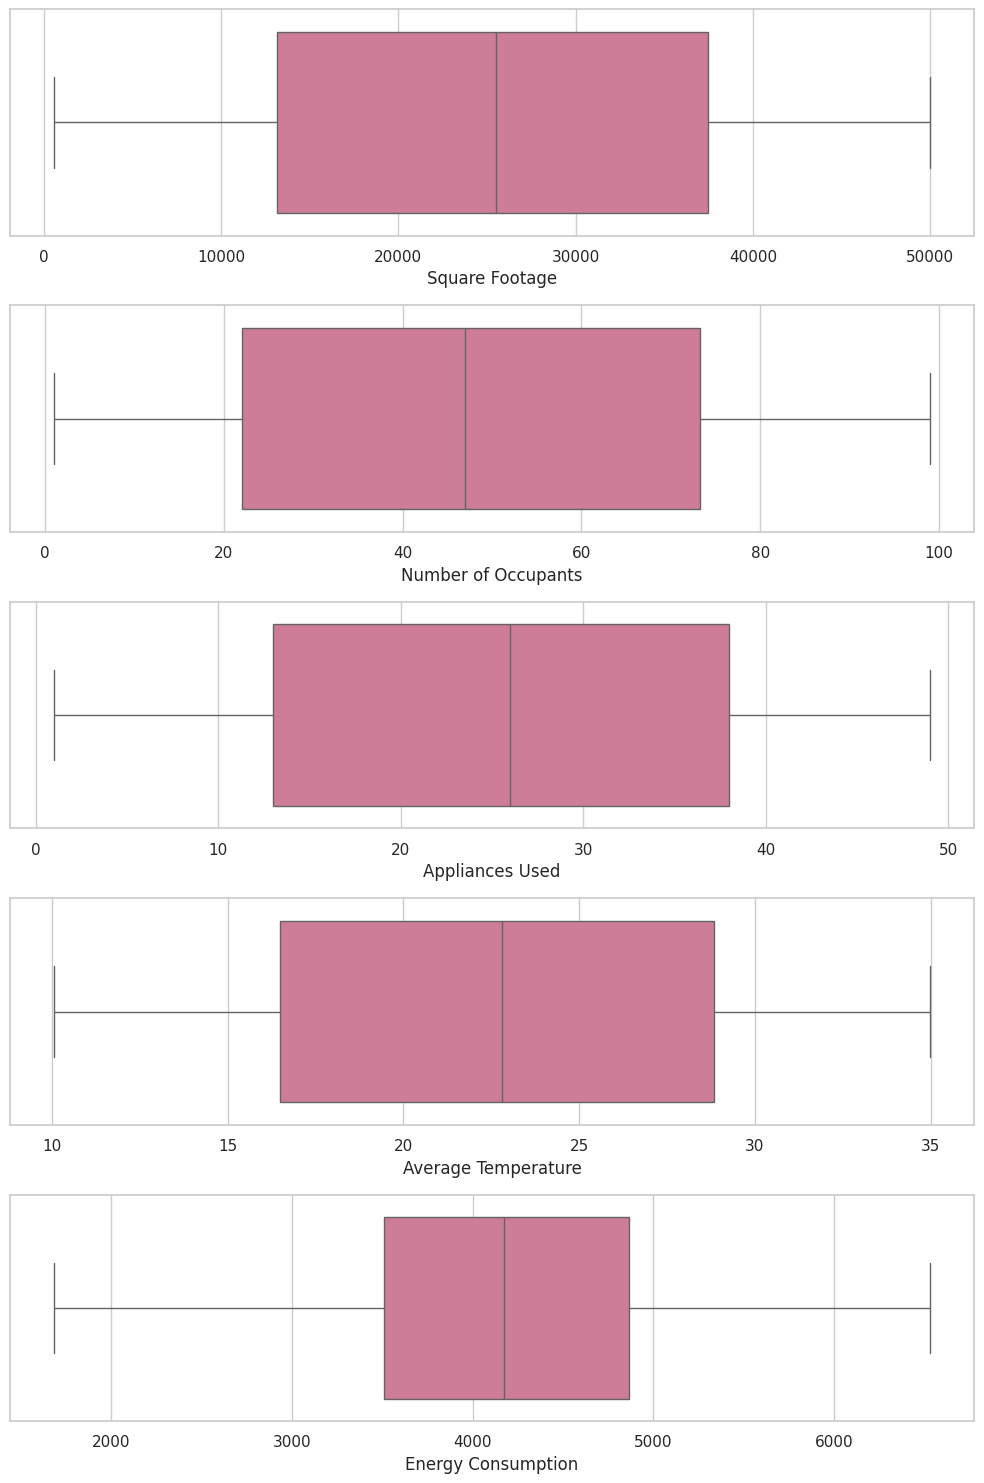

In [460]:
kolumny_num = df.select_dtypes(include=['number']).columns

wykres_num = len(kolumny_num)
fig, axes = plt.subplots(nrows=wykres_num, ncols=1, figsize=(10, 3 * wykres_num))

for i, col in enumerate(kolumny_num):
    sns.boxplot(x=df[col], ax=axes[i], color='palevioletred')

plt.tight_layout()
plt.show()

## Czyszczenie i podział danych

In [461]:
print("Brakujące wartości per kolumna:")
print(df.isnull().sum())

Brakujące wartości per kolumna:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


In [462]:
duplikat = df.duplicated().sum()

if duplikat > 0:
    energy = df.drop_duplicates()
    df("Duplikaty zostały usunięte.")
else:
    print("Brak duplikatów.")

Brak duplikatów.


In [463]:
from sklearn.model_selection import train_test_split
X = df.drop("Energy Consumption", axis=1) # cechy
y = df["Energy Consumption"].copy() # cel
print("Kolumny w X:", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Kolumny w X: ['Building Type', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Day of Week']


## Tworzenie potoku


In [464]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [465]:
kolumny_kat = ['Building Type', 'Day of Week']
kolumny_num = X_train.select_dtypes(include=['number']).columns

num_pipeline = Pipeline([
  ('std_scaler', StandardScaler()),])
kat_pipeline = Pipeline([
  ('one_hot', OneHotEncoder()),])

pipeline = ColumnTransformer([
  ("num_pipeline", num_pipeline, kolumny_num),
  ("cat_pipeline", kat_pipeline, kolumny_kat),])

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)


# Modele


## Linear Regression


In [466]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

y_pred_lin = lin_reg.predict(X_test_processed)

mse_lin = mean_squared_error(y_test, y_pred_lin)
print(f"MSE: {mse_lin:.4f}")
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
print(f"RMSE: {rmse_lin:.4f}")
r2_lin = lin_reg.score(X_test_processed, y_test)
print(f"R^2: {r2_lin:.4f}")

MSE: 0.0002
RMSE: 0.0137
R^2: 1.0000


## Random Forest

In [467]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

full_pipeline_rf = Pipeline([
    ('preprocessing', pipeline),
    ('rf_model', RandomForestRegressor(random_state=42))])

param_grid = [
    { 'rf_model__n_estimators': [10, 50, 150],
        'rf_model__max_depth': [10, 20, None],
        'rf_model__min_samples_split': [2, 5, 10]}]

grid_search = GridSearchCV(full_pipeline_rf, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"MSE: {mse_rf:.4f}")
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE: {rmse_rf:.4f}")
r2_rf = best_rf_model.score(X_test, y_test)
print(f"R^2: {r2_rf:.4f}")

Najlepsze parametry: {'rf_model__max_depth': 20, 'rf_model__min_samples_split': 2, 'rf_model__n_estimators': 150}
MSE: 15257.4477
RMSE: 123.5210
R^2: 0.9813


# Porównanie modeli

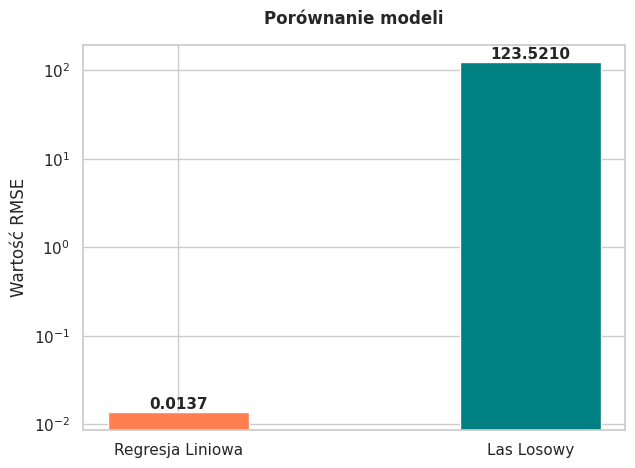

In [468]:
modele = ['Regresja Liniowa', 'Las Losowy']
wyniki_rmse = [rmse_lin, rmse_rf]

plt.figure(figsize=(7, 5))
słupki = plt.bar(modele, wyniki_rmse, color=['coral', 'teal'], width=0.4)

plt.yscale('log')

for słupek in słupki:
    wysokosc = słupek.get_height()
    plt.text(słupek.get_x() + słupek.get_width()/2., wysokosc,
             f'{wysokosc:.4f}',
             ha='center', va='bottom', fontsize=11, weight='bold')

plt.title('Porównanie modeli', pad=15, weight='bold')
plt.ylabel('Wartość RMSE')

plt.show()